In [184]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from scipy.stats import ttest_ind

# Data Load

In [190]:
df = pd.read_csv('salary.txt', sep=r'\s+', engine='python')
print(df.head(5))

   case  id sex    deg  yrdeg  field  startyr  year    rank  admin   salary
0     1   1   F  Other     92  Other       95    95  Assist      0   6684.0
1     2   2   M  Other     91  Other       94    94  Assist      0   4743.0
2     3   2   M  Other     91  Other       94    95  Assist      0   4881.0
3     4   4   M    PhD     96  Other       95    95  Assist      0   4231.0
4     5   6   M    PhD     66  Other       91    91    Full      1  11182.0


Find the first year each ID reached Assoc and Full

In [186]:
print(df['rank'].unique())
print(df['sex'].unique())

['Assist' 'Full' 'Assoc' nan]
['F' 'M']


In [187]:
print("Columns:", df.columns.tolist())
print(df.head())
print("Unique Ranks:", df['rank'].unique())
print("Gender counts:", df['sex'].value_counts())

Columns: ['case', 'id', 'sex', 'deg', 'yrdeg', 'field', 'startyr', 'year', 'rank', 'admin', 'salary']
   case  id sex    deg  yrdeg  field  startyr  year    rank  admin   salary
0     1   1   F  Other     92  Other       95    95  Assist      0   6684.0
1     2   2   M  Other     91  Other       94    94  Assist      0   4743.0
2     3   2   M  Other     91  Other       94    95  Assist      0   4881.0
3     4   4   M    PhD     96  Other       95    95  Assist      0   4231.0
4     5   6   M    PhD     66  Other       91    91    Full      1  11182.0
Unique Ranks: ['Assist' 'Full' 'Assoc' nan]
Gender counts: sex
M    15866
F     3926
Name: count, dtype: int64


# Numerical Summaries

In [191]:
# 3. Calculate Mean and Median Salaries
stats = df.groupby(['rank', 'sex'])['salary'].agg(['mean', 'median']).reset_index()

# 4. Calculate Promotion Percentage Increase
pivot_mean = stats.pivot(index='sex', columns='rank', values='mean')
pivot_mean['pct_increase'] = ((pivot_mean['Full'] - pivot_mean['Assoc']) / pivot_mean['Assoc']) * 100

print("--- Descriptive Statistics ---")
print(stats)
print("\n--- Percentage Increase from Assoc to Full ---")
print(pivot_mean[['pct_increase']])

--- Descriptive Statistics ---
     rank sex         mean     median
0  Assist   F  3390.336892  3411.7785
1  Assist   M  3387.458765  3314.0000
2   Assoc   F  4013.478557  4053.0000
3   Assoc   M  3965.813033  3860.3335
4    Full   F  5596.890050  5408.0000
5    Full   M  5865.128429  5586.5000

--- Percentage Increase from Assoc to Full ---
rank  pct_increase
sex               
F        39.452347
M        47.892207


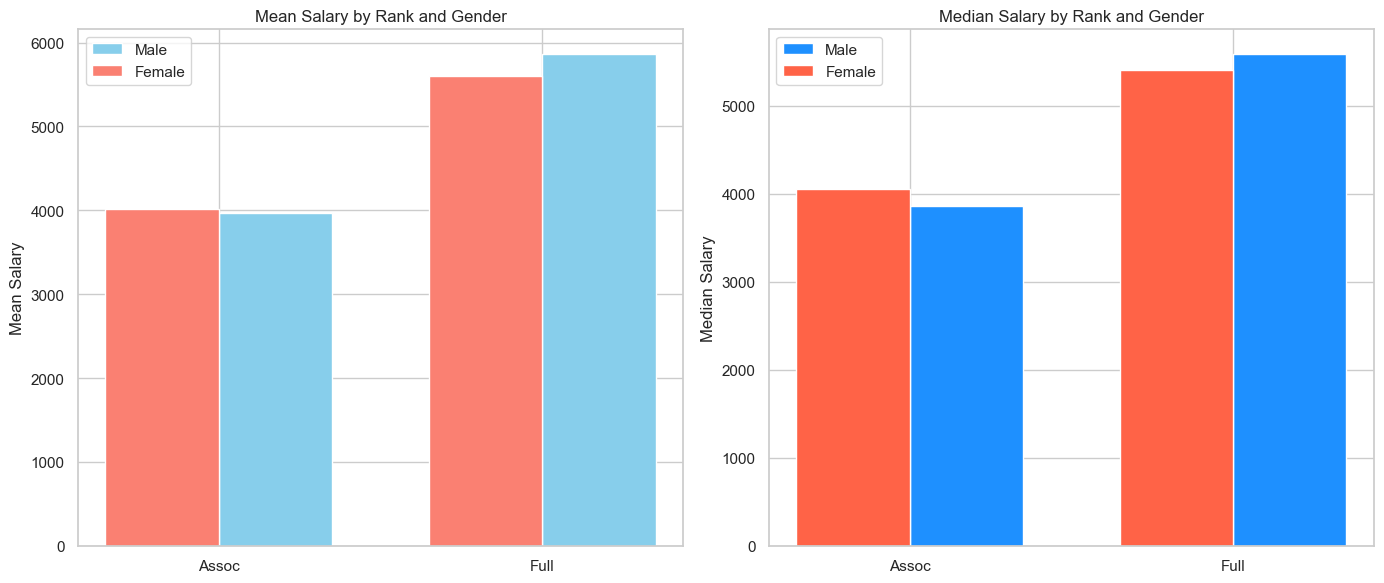

In [192]:
# --- VISUALIZATIONS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Mean Salaries (Bar Chart)
labels = ['Assoc', 'Full']
x = np.arange(len(labels))
width = 0.35

male_means = [stats[(stats['rank']=='Assoc') & (stats['sex']=='M')]['mean'].values[0],
              stats[(stats['rank']=='Full') & (stats['sex']=='M')]['mean'].values[0]]
female_means = [stats[(stats['rank']=='Assoc') & (stats['sex']=='F')]['mean'].values[0],
                stats[(stats['rank']=='Full') & (stats['sex']=='F')]['mean'].values[0]]

ax1.bar(x + width/2, male_means, width, label='Male', color='skyblue')
ax1.bar(x - width/2, female_means, width, label='Female', color='salmon')

ax1.set_ylabel('Mean Salary')
ax1.set_title('Mean Salary by Rank and Gender')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
# Plot 2: Median Salaries (Bar Chart)
male_medians = [stats[(stats['rank']=='Assoc') & (stats['sex']=='M')]['median'].values[0],
                stats[(stats['rank']=='Full') & (stats['sex']=='M')]['median'].values[0]]
female_medians = [stats[(stats['rank']=='Assoc') & (stats['sex']=='F')]['median'].values[0],
                  stats[(stats['rank']=='Full') & (stats['sex']=='F')]['median'].values[0]]

ax2.bar(x + width/2, male_medians, width, label='Male', color='dodgerblue')
ax2.bar(x - width/2, female_medians, width, label='Female', color='tomato')

ax2.set_ylabel('Median Salary')
ax2.set_title('Median Salary by Rank and Gender')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()

plt.tight_layout()
plt.show()

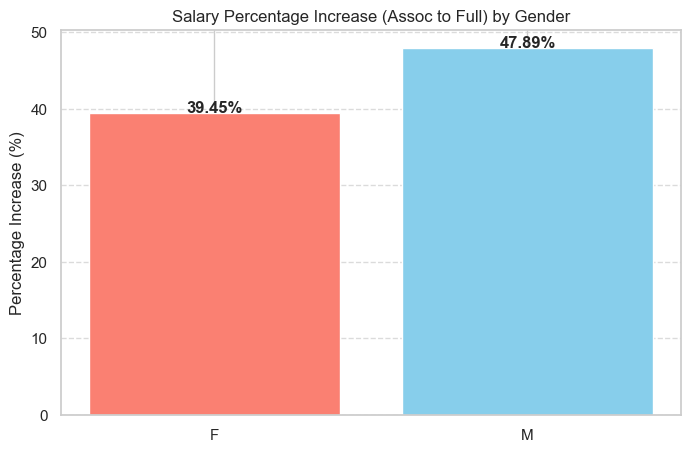

In [193]:
plt.figure(figsize=(8, 5))
plt.bar(pivot_mean.index, pivot_mean['pct_increase'], color=['salmon', 'skyblue'])
plt.title('Salary Percentage Increase (Assoc to Full) by Gender')
plt.ylabel('Percentage Increase (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(pivot_mean['pct_increase']):
    plt.text(i, val + 0.1, f'{val:.2f}%', ha='center', fontweight='bold')

plt.show()

At the Associate (Assoc) level, women actually have a slightly higher mean salary than men (approx. 4,013 vs. 3,965). However, the "Percentage Increase" chart shows a stark difference in career progression. Men receive a 47.89% increase when moving from Associate to Full Professor, while women only see a 39.45% increase. By the time they reach Full Professor, men have surpassed women in both mean and median salary.

In [137]:
model_q2 = smf.ols('salary ~ sex * rank + field + yrdeg + admin', data=df).fit()

print(model_q2.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     1403.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:23:43   Log-Likelihood:            -1.7347e+05
No. Observations:               19788   AIC:                         3.470e+05
Df Residuals:                   19778   BIC:                         3.470e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -2593

The coefficient for sex is 337.27. This means that when holding all other factors (rank, degree, field, years, admin status) constant, being male is associated with a 337.27 higher salary than being female. Since the p-value is 0.000, this is statistically significant. Every additional year adds 
221.46 to the salary, and having an administrative role (admin) adds a substantial 811.70. Moving to a Full Professor rank adds 1,863.53 compared to the baseline (likely Assistant Professor), which is the single largest predictor in the model.

In [136]:
anova_formula = 'salary ~ C(sex) * C(rank)'
anova_model = smf.ols(anova_formula, data=df).fit()
anova_results = anova_lm(anova_model, typ=2)

print("\n--- Two-Way ANOVA Results ---")
print(anova_results)


--- Two-Way ANOVA Results ---
                      sum_sq       df            F    PR(>F)
C(sex)          1.124226e+07      1.0     3.986383  0.045883
C(rank)         2.085969e+10      2.0  3698.310818  0.000000
C(sex):C(rank)  5.554374e+07      2.0     9.847606  0.000053
Residual        5.578849e+10  19782.0          NaN       NaN


 The p-value is extremely low ($0.000053$). This confirms that the effect of rank on salary depends on gender. This statistically supports what the Percentage Increase graph showed: the financial gain for reaching the highest rank is significantly different for men than it is for women.

In [195]:
# 1. Isolate all Associate and Full records
assoc_records = df2[df2['rank'] == 'Assoc'].sort_values(['id', 'year'])
full_records = df2[df2['rank'] == 'Full'].sort_values(['id', 'year'])

# 2. Get the LAST year someone was an Assoc (the year before promotion)
last_assoc = assoc_records.groupby('id').last().reset_index()

# 3. Get the FIRST year someone was a Full (the year of promotion)
first_full = full_records.groupby('id').first().reset_index()

# 4. Merge them together into promo_df
# This ensures we only keep people who actually experienced a promotion
promo_df = pd.merge(
    last_assoc[['id', 'salary', 'year']], 
    first_full, 
    on='id', 
    suffixes=('_assoc', '_full')
)

# 5. Filter for 'Sequential' promotions (Optional but recommended)
# This ensures they were promoted in the very next year (e.g., year 85 to 86)
promo_df = promo_df[promo_df['year_full'] == promo_df['year_assoc'] + 1]
promo_df['log_salary_full'] = np.log(promo_df['salary_full'])
promo_df['log_salary_assoc'] = np.log(promo_df['salary_assoc'])
promo_df['years_at_inst'] = promo_df['year_full'] - promo_df['startyr']
promo_df['years_since_degree'] = promo_df['year_full'] - promo_df['yrdeg']
promo_df['pct_jump'] = promo_df['log_salary_full'] - promo_df['log_salary_assoc']
formula_pct = 'pct_jump ~ C(sex) + yrdeg + C(field) + C(deg) + admin + years_since_degree + years_at_inst'
model_pct = smf.ols(formula_pct, data=promo_df).fit()
print(model_pct.summary())

                            OLS Regression Results                            
Dep. Variable:               pct_jump   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     4.078
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           4.47e-05
Time:                        14:40:42   Log-Likelihood:                 680.09
No. Observations:                 534   AIC:                            -1340.
Df Residuals:                     524   BIC:                            -1297.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2571      0

Does Wage Discrimination Exist in Promotions?
No
Coefficient for C(sex)[T.M]: -0.0058
P-value: 0.544
Men actually received about 0.58% less of a percentage jump than women, but because the p-value is so high (0.544), this difference is statistically insignificant. You cannot claim there is a gender difference in the promotion raise magnitude.

What Does Affect the Promotion Jump?
Two variables actually matter here, and they aren't gender:
C(field)[T.Other] (P = 0.007): Professors in the "Other" fields received about a 3% smaller raise (-0.0298) compared to the reference group (likely Arts).
years_since_degree (P = 0.007): For every additional year that has passed since a professor got their degree, their promotion jump decreases by about 0.28%. This suggests that "late bloomers" or those who take longer to reach Full Professor see slightly smaller percentage increases than those who move up quickly.